In [1]:
!pip install numba

In [2]:
!pip install pandas

In [ ]:
!pip install scikit-learn

In [3]:
!pip install matplotlib

In [4]:
!nvidia-smi

Thu Apr  9 09:45:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import pandas as pd
import numpy as np
from numba import cuda
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [10]:
from google.colab import files
uploaded = files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [11]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

In [28]:
#eda
print(df.head())
print(df.info())
print(df.describe())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    1  22.0      1      0   7.2500         2
1         1       1    0  38.0      1      0  71.2833         0
2         1       3    0  26.0      0      0   7.9250         2
3         1       1    0  35.0      1      0  53.1000         2
4         0       3    1  35.0      0      0   8.0500         2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB
None
         Survived      Pclass         Sex         Age       SibSp 

In [16]:
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

/tmp/ipykernel_3969/748597328.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_3969/748597328.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [17]:
X = df.drop('Survived', axis=1).values.astype(np.float32)
y = df['Survived'].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
@cuda.jit(device=True)
def sigmoid(x):
    return 1.0 / (1.0 + math.exp(-x))

In [19]:
@cuda.jit
def predict_kernel(X, weights, bias, preds):
    i = cuda.grid(1)

    if i < X.shape[0]:
        z = 0.0

        for j in range(X.shape[1]):
            z += X[i, j] * weights[j]

        z += bias
        preds[i] = sigmoid(z)

In [20]:
@cuda.jit
def gradient_kernel(X, y, weights, bias, grad_w, grad_b):
    i = cuda.grid(1)

    if i < X.shape[0]:
        z = 0.0

        for j in range(X.shape[1]):
            z += X[i, j] * weights[j]

        z += bias

        pred = sigmoid(z)
        error = pred - y[i]

        for j in range(X.shape[1]):
            cuda.atomic.add(grad_w, j, error * X[i, j])

        cuda.atomic.add(grad_b, 0, error)

In [21]:
n_features = X_train.shape[1]

weights = np.zeros(n_features, dtype=np.float32)
bias = np.float32(0.0)

d_X = cuda.to_device(X_train)
d_y = cuda.to_device(y_train)
d_weights = cuda.to_device(weights)

threads_per_block = 256
blocks = (X_train.shape[0] + threads_per_block - 1) // threads_per_block

lr = 0.01
epochs = 100



In [22]:
for epoch in range(epochs):

    grad_w = np.zeros(n_features, dtype=np.float32)
    grad_b = np.zeros(1, dtype=np.float32)

    d_grad_w = cuda.to_device(grad_w)
    d_grad_b = cuda.to_device(grad_b)

    gradient_kernel[blocks, threads_per_block](
        d_X, d_y, d_weights, bias, d_grad_w, d_grad_b
    )

    grad_w = d_grad_w.copy_to_host() / X_train.shape[0]
    grad_b = d_grad_b.copy_to_host()[0] / X_train.shape[0]

    weights -= lr * grad_w
    bias -= lr * grad_b

    d_weights = cuda.to_device(weights)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [23]:
d_Xtest = cuda.to_device(X_test)

preds = np.zeros(X_test.shape[0], dtype=np.float32)
d_preds = cuda.to_device(preds)

blocks_test = (X_test.shape[0] + threads_per_block - 1) // threads_per_block

predict_kernel[blocks_test, threads_per_block](d_Xtest, d_weights, bias, d_preds)

preds = d_preds.copy_to_host()

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [24]:
pred_labels = (preds >= 0.5).astype(np.int32)

accuracy = np.mean(pred_labels == y_test)

print("Accuracy:", accuracy)

Accuracy: 0.6256983240223464


In [26]:
tp = np.sum((pred_labels == 1) & (y_test == 1))
tn = np.sum((pred_labels == 0) & (y_test == 0))
fp = np.sum((pred_labels == 1) & (y_test == 0))
fn = np.sum((pred_labels == 0) & (y_test == 1))

print("Confusion Matrix:")
print(f"TP: {tp}, FP: {fp}")
print(f"FN: {fn}, TN: {tn}")

Confusion Matrix:
TP: 8, FP: 1
FN: 66, TN: 104


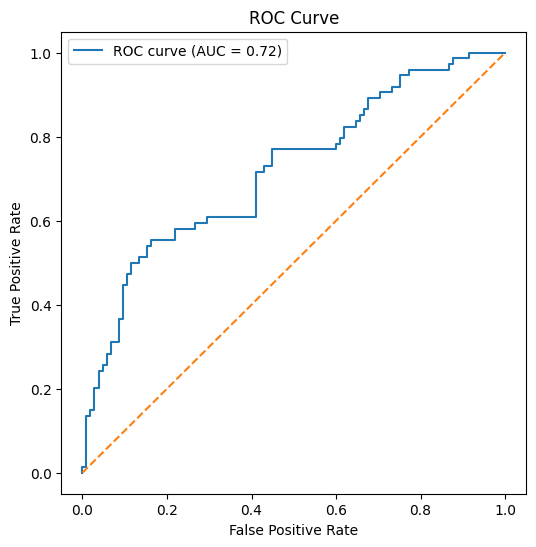

In [25]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.show()

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [30]:
scaler.fit(X_train)

StandardScaler()

In [31]:
samples_scaled = scaler.transform(samples).astype(np.float32)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [32]:
samples = samples[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
samples_scaled = scaler.transform(samples).astype(np.float32)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [33]:
# ===== SAMPLE DATA =====
samples = pd.DataFrame([
    [3, 'male', 22, 1, 0, 7.25, 'S'],
    [1, 'female', 38, 1, 0, 71.28, 'C'],
    [2, 'female', 26, 0, 0, 13.00, 'S']
], columns=['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked'])

samples['Sex'] = le_sex.transform(samples['Sex'])
samples['Embarked'] = le_embarked.transform(samples['Embarked'])


# ===== SCALING =====
samples_scaled = scaler.transform(samples).astype(np.float32)


# ===== MOVE TO GPU =====
d_samples = cuda.to_device(samples_scaled)

preds = np.zeros(samples.shape[0], dtype=np.float32)
d_preds = cuda.to_device(preds)


# ===== CUDA PREDICTION =====
threads_per_block = 256
blocks = (samples.shape[0] + threads_per_block - 1) // threads_per_block

predict_kernel[blocks, threads_per_block](
    d_samples, d_weights, bias, d_preds
)


# ===== RESULTS =====
preds = d_preds.copy_to_host()

samples['Survival_Prob'] = preds
samples['Prediction'] = [
    'Survived' if p > 0.5 else 'Not Survived' for p in preds
]


print("===== PREDICTION RESULTS =====")
samples

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


===== PREDICTION RESULTS =====


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survival_Prob,Prediction
0,3,1,22,1,0,7.25,2,0.449395,Not Survived
1,1,0,38,1,0,71.28,0,0.588225,Survived
2,2,0,26,0,0,13.00,2,0.556398,Survived
